# Inferencia y Backtesting — Sistema Hidráulico LSTM / GRU

Notebook **completamente independiente** del entrenamiento.  
Carga los datos originales, reconstruye el conjunto de backtesting con la 
**misma semilla y partición** usada durante el entrenamiento, 
carga los modelos `.keras` guardados y ejecuta la evaluación final.

**Requisitos previos:**
- Carpeta `processed/` con los 17 archivos `.parquet` de sensores
- Carpeta `models/` con los 10 archivos `.keras` generados durante el entrenamiento

**Estructura del notebook:**
1. Importaciones y configuración del dispositivo
2. Carga y preprocesamiento de datos
3. Reconstrucción del conjunto de backtesting (15%)
4. Carga de modelos entrenados
5. Backtesting — métricas y visualizaciones


## 1. Importaciones y configuración del dispositivo

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix,
                             precision_recall_curve, auc)
from keras.models import load_model


In [2]:
# ── Detección automática GPU / CPU ────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    DEVICE = '/GPU:0'
    print(f'✓ GPU detectada: {[g.name for g in gpus]}')
    print(f'  Inferencia en: {DEVICE}')
else:
    DEVICE = '/CPU:0'
    print(f'⚠ Sin GPU — inferencia en CPU ({DEVICE})')

print(f'TensorFlow {tf.__version__}')


⚠ Sin GPU — inferencia en CPU (/CPU:0)
TensorFlow 2.16.1


In [3]:
# ── Estilo global de gráficas ─────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':      'serif',
    'axes.titlesize':   14,
    'axes.labelsize':   12,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
    'legend.fontsize':  10,
})


## 2. Carga y preprocesamiento de datos

Se cargan exactamente los mismos archivos y se aplica el mismo preprocesamiento 
que en el entrenamiento para garantizar que el conjunto de backtesting sea idéntico.


In [4]:
# ── Lista de archivos de sensores ────────────────────────────────────────────
file_list = [
    './processed/PS1_filtrados.parquet',
    './processed/PS2_filtrados.parquet',
    './processed/PS3_filtrados.parquet',
    './processed/PS4_filtrados.parquet',
    './processed/PS5_filtrados.parquet',
    './processed/PS6_filtrados.parquet',
    './processed/EPS1_filtrados.parquet',
    './processed/FS1_filtrados.parquet',
    './processed/FS2_filtrados.parquet',
    './processed/TS1_filtrados.parquet',
    './processed/TS2_filtrados.parquet',
    './processed/TS3_filtrados.parquet',
    './processed/TS4_filtrados.parquet',
    './processed/VS1_filtrados.parquet',
    './processed/CE_filtrados.parquet',
    './processed/CP_filtrados.parquet',
    './processed/SE_filtrados.parquet',
]

targets_names = ['cooler', 'valve', 'leakage', 'accumulator', 'stable']

def file_read(file):
    return pd.read_parquet(file).to_numpy()


In [5]:
# ── Lectura de sensores ───────────────────────────────────────────────────────
data_dict = {}
for file in file_list:
    data      = file_read(file)
    if np.isnan(data[0]).all():
        data  = data[1:]
    data      = data.T
    file_name = file.split('/')[-1].split('.')[0]
    data_dict[file_name] = data
    print(f'{file_name:20s}  {data.shape}')

ans_df = pd.read_parquet('./processed/profile.parquet')
ans_df.columns = targets_names
print(f'\nTargets cargados: {ans_df.shape}')


PS1_filtrados         (2205, 6000)
PS2_filtrados         (2205, 6000)
PS3_filtrados         (2205, 6000)
PS4_filtrados         (2205, 6000)
PS5_filtrados         (2205, 6000)
PS6_filtrados         (2205, 6000)
EPS1_filtrados        (2205, 6000)
FS1_filtrados         (2205, 600)
FS2_filtrados         (2205, 600)
TS1_filtrados         (2205, 60)
TS2_filtrados         (2205, 60)
TS3_filtrados         (2205, 60)
TS4_filtrados         (2205, 60)
VS1_filtrados         (2205, 60)
CE_filtrados          (2205, 60)
CP_filtrados          (2205, 60)
SE_filtrados          (2205, 60)

Targets cargados: (2205, 5)


In [6]:
# ── Construcción del tensor de entrada ───────────────────────────────────────
def create_time_data(data_dict, window_size=1):
    x = None
    for key in data_dict:
        v = data_dict[key]
        if v.shape[1] == 6000:
            v = v[:, ::100]
        elif v.shape[1] == 600:
            v = v[:, ::10]
        assert v.shape[1] == 60

        v = np.apply_along_axis(
            lambda row: np.convolve(row, np.ones(window_size) / window_size, mode='valid'),
            axis=1, arr=v
        )
        scaler = MinMaxScaler()
        v = scaler.fit_transform(v)

        shape = (1, v.shape[0], 61 - window_size)
        x = v.reshape(shape) if x is None else np.concatenate((x, v.reshape(shape)))

    return np.transpose(x, (1, 2, 0))

x = create_time_data(data_dict, window_size=5)
y = ans_df['stable'].values
print(f'Tensor x: {x.shape}  |  Vector y: {y.shape}')
print(f'Distribución de y — 0: {(y==0).sum()}  |  1: {(y==1).sum()}')


Tensor x: (2205, 56, 17)  |  Vector y: (2205,)
Distribución de y — 0: 1449  |  1: 756


## 3. Reconstrucción del conjunto de backtesting

Se aplica **exactamente la misma partición** (`random_state=42`, `stratify=y`) 
que se usó durante el entrenamiento.  
Esto garantiza que `x_backtest` contiene los mismos 332 ejemplos 
que nunca fueron expuestos al modelo.


In [7]:
# ── Partición idéntica a la del entrenamiento ─────────────────────────────────
#   Paso 1: separar 30% como holdout (estratificado)
#   Paso 2: dividir el holdout 50/50 → validación (15%) y backtesting (15%)

_, x_holdout, _, y_holdout = train_test_split(
    x, y, test_size=0.30, random_state=42, stratify=y
)
_, x_backtest, _, y_backtest = train_test_split(
    x_holdout, y_holdout, test_size=0.50, random_state=42, stratify=y_holdout
)

print(f'Conjunto de backtesting: {x_backtest.shape[0]} muestras')
print(f'  y_backtest — 0: {(y_backtest==0).sum()}  |  1: {(y_backtest==1).sum()}')


Conjunto de backtesting: 331 muestras
  y_backtest — 0: 217  |  1: 114


## 4. Carga de modelos entrenados

Se cargan los 10 archivos `.keras` desde la carpeta `models/`.  
Si alguno no se encuentra, se reporta el error y se omite de la evaluación.


In [8]:
# ── Carga de los 10 modelos desde disco ──────────────────────────────────────
modelos = {}
for mt in ['lstm', 'gru']:
    for exp in range(1, 6):
        path = f'models/modelo_{mt}_exp{exp}.keras'
        try:
            modelos[f'{mt}_exp{exp}'] = load_model(path)
            print(f'✓  {path}')
        except Exception as e:
            print(f'✗  {path}  →  {e}')

print(f'\nModelos cargados: {len(modelos)} / 10')


✓  models/modelo_lstm_exp1.keras
✓  models/modelo_lstm_exp2.keras
✓  models/modelo_lstm_exp3.keras
✓  models/modelo_lstm_exp4.keras
✓  models/modelo_lstm_exp5.keras
✓  models/modelo_gru_exp1.keras
✓  models/modelo_gru_exp2.keras
✓  models/modelo_gru_exp3.keras
✓  models/modelo_gru_exp4.keras
✓  models/modelo_gru_exp5.keras

Modelos cargados: 10 / 10


## 5. Backtesting

Evaluación de todos los modelos sobre el conjunto de prueba independiente (15%).  
Estos datos **nunca fueron vistos** durante el entrenamiento ni la validación.


In [9]:
# ── Cálculo de métricas para todos los modelos ───────────────────────────────
# Se almacenan también las curvas PR y las matrices de confusión para graficar.

resultados   = []
pred_probs   = {}   # probabilidades crudas por modelo (para PR curves)
conf_matrices = {}  # matrices de confusión por modelo

for key, modelo in modelos.items():
    mt_k, exp_str = key.split('_exp')

    with tf.device(DEVICE):
        probs  = modelo.predict(x_backtest, verbose=0).flatten()
    labels = (probs > 0.5).astype(int)

    pc, rc, _ = precision_recall_curve(y_backtest, probs)
    auc_pr    = auc(rc, pc)

    pred_probs[key]    = probs
    conf_matrices[key] = confusion_matrix(y_backtest, labels)

    resultados.append({
        'Modelo':      mt_k.upper(),
        'Configuración': f'Config. {exp_str}',
        'Exactitud':   round(accuracy_score(y_backtest, labels), 4),
        'Precisión':   round(precision_score(y_backtest, labels, zero_division=0), 4),
        'Recall':      round(recall_score(y_backtest, labels, zero_division=0), 4),
        'F1-Score':    round(f1_score(y_backtest, labels, zero_division=0), 4),
        'AUC-PR':      round(auc_pr, 4),
    })

df_bt = pd.DataFrame(resultados)
print('Backtesting — resultados completos:')
print(df_bt.to_string(index=False))
df_bt


Backtesting — resultados completos:
Modelo Configuración  Exactitud  Precisión  Recall  F1-Score  AUC-PR
  LSTM     Config. 1     0.9124     0.8829  0.8596    0.8711  0.9704
  LSTM     Config. 2     0.9003     0.8522  0.8596    0.8559  0.8343
  LSTM     Config. 3     0.9154     0.8308  0.9474    0.8852  0.8530
  LSTM     Config. 4     0.3444     0.3444  1.0000    0.5124  0.6722
  LSTM     Config. 5     0.9305     0.9596  0.8333    0.8920  0.9731
   GRU     Config. 1     0.9456     0.9444  0.8947    0.9189  0.9857
   GRU     Config. 2     0.8882     0.8080  0.8860    0.8452  0.8466
   GRU     Config. 3     0.6556     0.0000  0.0000    0.0000  0.6722
   GRU     Config. 4     0.3444     0.3444  1.0000    0.5124  0.6722
   GRU     Config. 5     0.9517     0.9455  0.9123    0.9286  0.9870


,Modelo,Configuración,Exactitud,Precisión,Recall,F1-Score,AUC-PR
0,LSTM,Config. 1,0.9124,0.8829,0.8596,0.8711,0.9704
1,LSTM,Config. 2,0.9003,0.8522,0.8596,0.8559,0.8343
2,LSTM,Config. 3,0.9154,0.8308,0.9474,0.8852,0.8530
3,LSTM,Config. 4,0.3444,0.3444,1.0000,0.5124,0.6722
4,LSTM,Config. 5,0.9305,0.9596,0.8333,0.8920,0.9731
5,GRU,Config. 1,0.9456,0.9444,0.8947,0.9189,0.9857
6,GRU,Config. 2,0.8882,0.8080,0.8860,0.8452,0.8466
7,GRU,Config. 3,0.6556,0.0000,0.0000,0.0000,0.6722
8,GRU,Config. 4,0.3444,0.3444,1.0000,0.5124,0.6722
9,GRU,Config. 5,0.9517,0.9455,0.9123,0.9286,0.9870


### 5.1 Comparativa de métricas por configuración

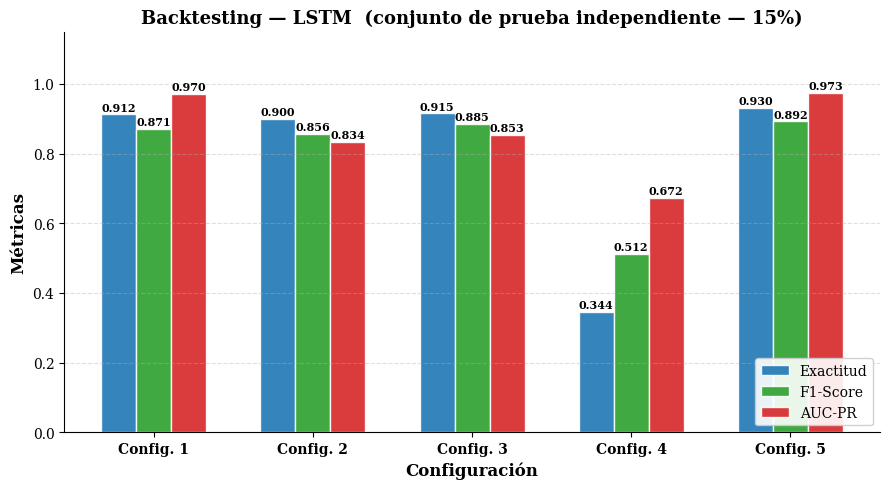

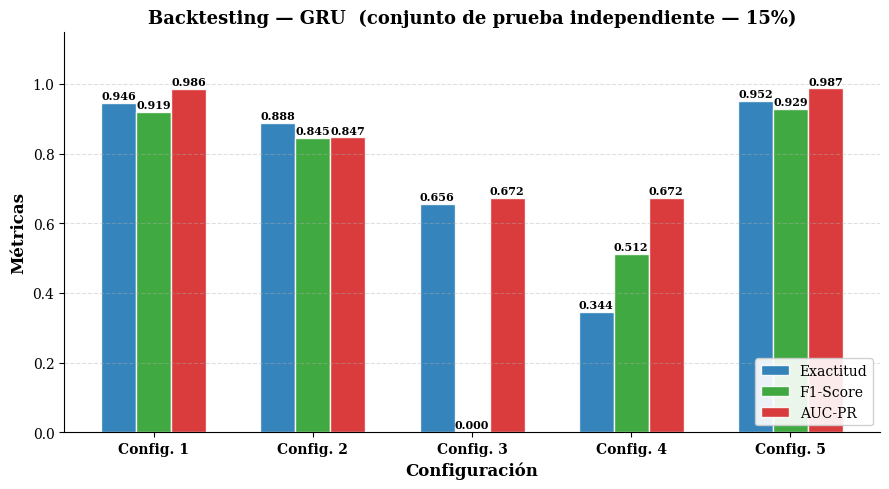

In [10]:
# ── Gráfica de barras — Exactitud, F1-Score y AUC-PR por familia ─────────────
for mt in ['lstm', 'gru']:
    MT     = mt.upper()
    subset = df_bt[df_bt['Modelo'] == MT].reset_index(drop=True)
    x_pos  = np.arange(len(subset))
    ancho  = 0.22
    etiq   = subset['Configuración'].tolist()

    fig, ax = plt.subplots(figsize=(9, 5))
    b1 = ax.bar(x_pos - ancho, subset['Exactitud'], ancho,
                label='Exactitud', color='#1f77b4', alpha=0.9, edgecolor='white')
    b2 = ax.bar(x_pos,         subset['F1-Score'],  ancho,
                label='F1-Score',  color='#2ca02c', alpha=0.9, edgecolor='white')
    b3 = ax.bar(x_pos + ancho, subset['AUC-PR'],    ancho,
                label='AUC-PR',    color='#d62728', alpha=0.9, edgecolor='white')

    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(etiq, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_title(f'Backtesting — {MT}  (conjunto de prueba independiente — 15%)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Configuración', fontsize=12, fontweight='bold')
    ax.set_ylabel('Métricas',      fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc='lower right', framealpha=0.9)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout(); plt.show()


### 5.2 Curvas Precisión-Sensibilidad

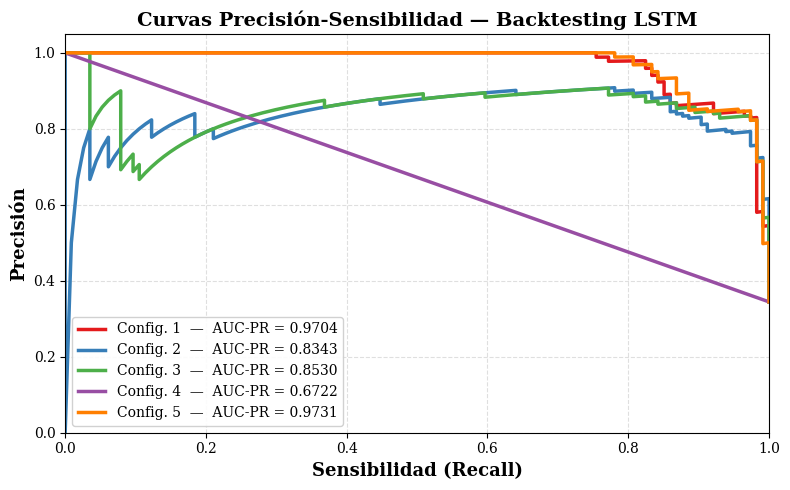

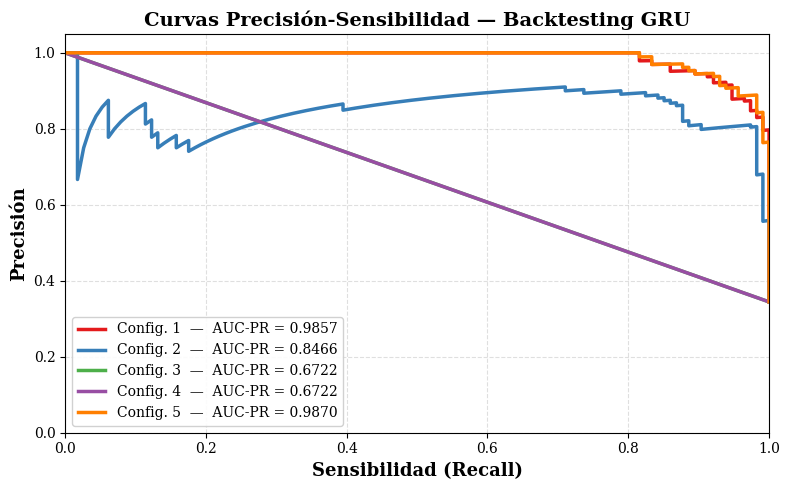

In [11]:
# ── Curvas Precisión-Sensibilidad por familia ─────────────────────────────────
colores = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

for mt in ['lstm', 'gru']:
    MT = mt.upper()
    plt.figure(figsize=(8, 5))
    for exp, c in zip(range(1, 6), colores):
        key = f'{mt}_exp{exp}'
        if key not in pred_probs:
            continue
        pc, rc, _ = precision_recall_curve(y_backtest, pred_probs[key])
        auc_v     = auc(rc, pc)
        plt.plot(rc, pc, lw=2.5, color=c,
                 label=f'Config. {exp}  —  AUC-PR = {auc_v:.4f}')

    plt.xlabel('Sensibilidad (Recall)', fontsize=13, fontweight='bold')
    plt.ylabel('Precisión',             fontsize=13, fontweight='bold')
    plt.title(f'Curvas Precisión-Sensibilidad — Backtesting {MT}',
              fontsize=14, fontweight='bold')
    plt.legend(loc='lower left', fontsize=10, framealpha=0.9)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.xlim([0, 1]); plt.ylim([0, 1.05])
    plt.tight_layout(); plt.show()


### 5.3 Clase real vs Clase predicha (Jitter plot)

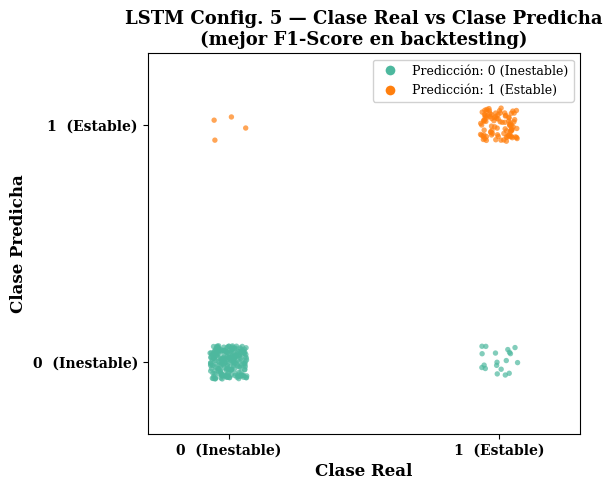

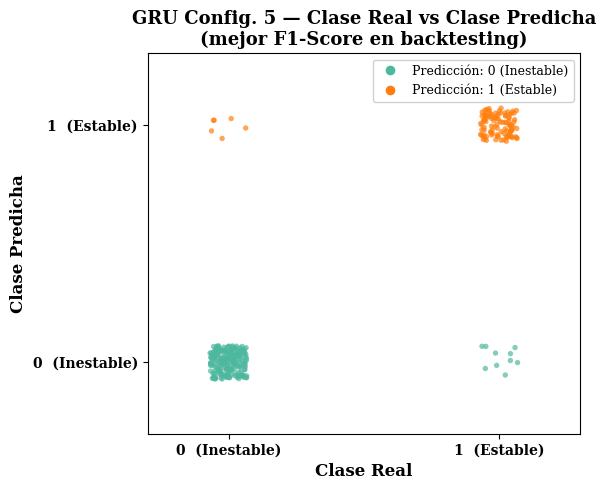

In [12]:
# ── Jitter plot — Clase Real vs Clase Predicha ────────────────────────────────
# Se muestra el mejor modelo por familia (mayor F1-Score).

for mt in ['lstm', 'gru']:
    MT       = mt.upper()
    best_row = df_bt[df_bt['Modelo'] == MT].sort_values('F1-Score', ascending=False).iloc[0]
    best_exp = int(best_row['Configuración'].split('.')[1].strip())
    key      = f'{mt}_exp{best_exp}'

    labels_best = (pred_probs[key] > 0.5).astype(int)
    rng         = np.random.default_rng(seed=42)
    jit         = 0.07

    x_real  = y_backtest.flatten()  + rng.uniform(-jit, jit, size=len(y_backtest))
    y_pred  = labels_best.flatten() + rng.uniform(-jit, jit, size=len(labels_best))
    colores = np.where(labels_best == 0, '#4db89e', '#ff7f0e')

    plt.figure(figsize=(6, 5))
    plt.scatter(x_real, y_pred, c=colores, s=15, alpha=0.7, edgecolors='none')

    leyenda = [
        mlines.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor='#4db89e', markersize=8,
                      label='Predicción: 0 (Inestable)'),
        mlines.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor='#ff7f0e', markersize=8,
                      label='Predicción: 1 (Estable)'),
    ]
    plt.legend(handles=leyenda, fontsize=9, framealpha=0.9)

    plt.title(f'{MT} Config. {best_exp} — Clase Real vs Clase Predicha\n(mejor F1-Score en backtesting)',
              fontsize=13, fontweight='bold')
    plt.xlabel('Clase Real',     fontsize=12, fontweight='bold')
    plt.ylabel('Clase Predicha', fontsize=12, fontweight='bold')
    plt.xticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
    plt.yticks([0, 1], ['0  (Inestable)', '1  (Estable)'], fontweight='bold')
    plt.xlim(-0.3, 1.3); plt.ylim(-0.3, 1.3)
    plt.grid(False)
    plt.tight_layout(); plt.show()


### 5.4 Matrices de Confusión

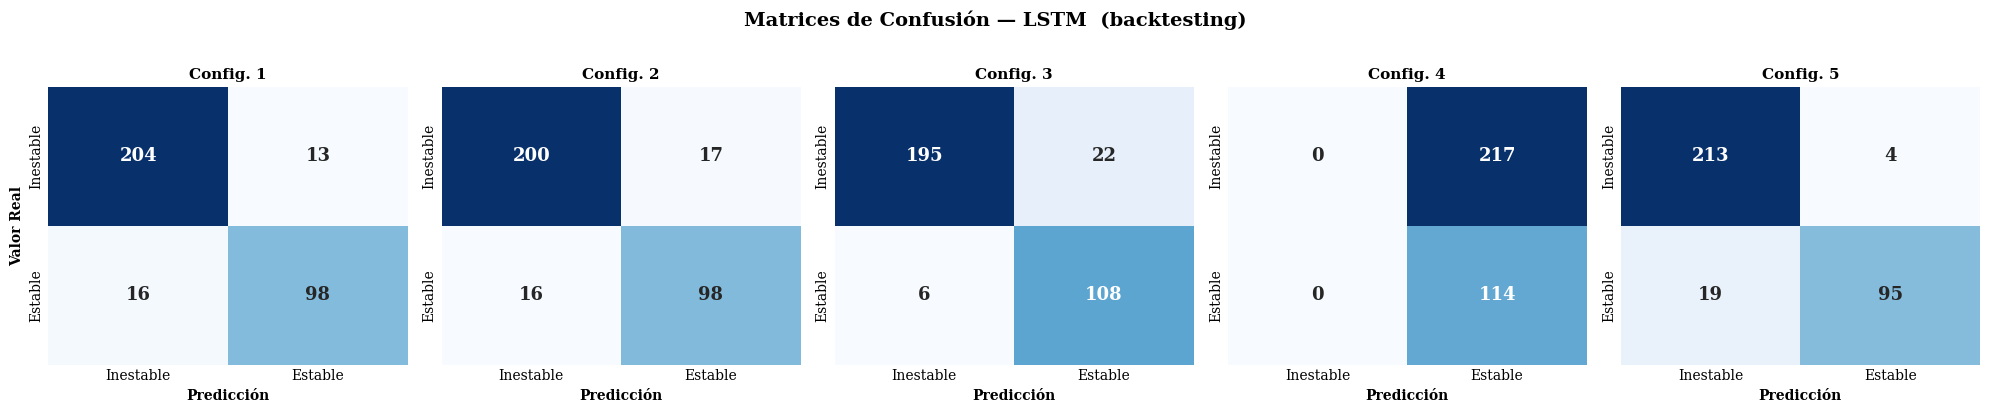

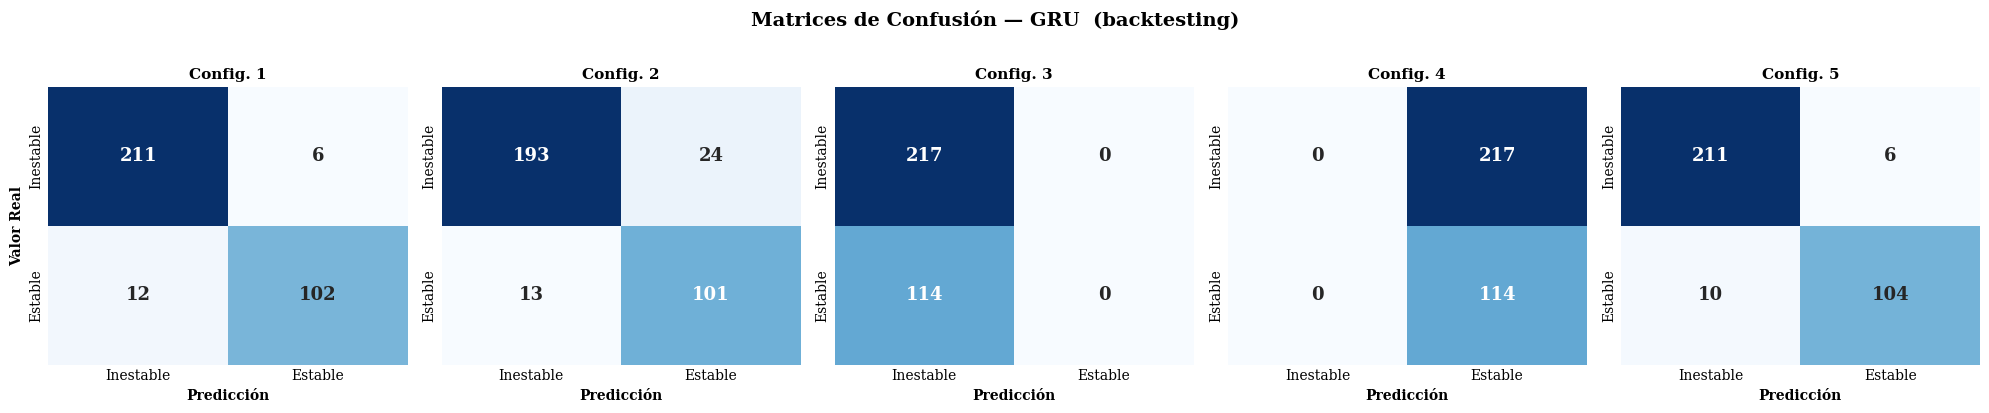

In [13]:
# ── Matrices de Confusión — todas las configuraciones por familia ─────────────
for mt in ['lstm', 'gru']:
    MT  = mt.upper()
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f'Matrices de Confusión — {MT}  (backtesting)',
                 fontsize=14, fontweight='bold', y=1.02)

    for exp, ax in zip(range(1, 6), axes):
        key = f'{mt}_exp{exp}'
        if key not in conf_matrices:
            ax.axis('off')
            continue
        cm = conf_matrices[key]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=['Inestable', 'Estable'],
                    yticklabels=['Inestable', 'Estable'],
                    annot_kws={'size': 13, 'fontweight': 'bold'},
                    linewidths=0, linecolor='none', ax=ax)
        ax.tick_params(axis='both', which='both', length=0)
        ax.set_title(f'Config. {exp}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Predicción',     fontsize=10, fontweight='bold')
        ax.set_ylabel('Valor Real' if exp == 1 else '', fontsize=10, fontweight='bold')

    plt.tight_layout(); plt.show()


### 5.5 Tabla resumen final

In [15]:
# ── Tabla resumen ordenada por F1-Score descendente ──────────────────────────
df_summary = df_bt.sort_values(['Modelo', 'F1-Score'], ascending=[True, False])
df_summary = df_summary.reset_index(drop=True)

print('='*70)
print('  RESULTADOS FINALES — BACKTESTING (15% datos no vistos)')
print('='*70)
print(df_summary.to_string(index=False))
print('='*70)
print(f"\nMejor LSTM: {df_bt[df_bt['Modelo']=='LSTM'].sort_values('AUC-PR').iloc[-1]['Configuración']}  "
      f"AUC-PR={df_bt[df_bt['Modelo']=='LSTM']['AUC-PR'].max():.4f}")
print(f"Mejor GRU:  {df_bt[df_bt['Modelo']=='GRU'].sort_values('AUC-PR').iloc[-1]['Configuración']}  "
      f"AUC-PR={df_bt[df_bt['Modelo']=='GRU']['AUC-PR'].max():.4f}")
df_summary


  RESULTADOS FINALES — BACKTESTING (15% datos no vistos)
Modelo Configuración  Exactitud  Precisión  Recall  F1-Score  AUC-PR
   GRU     Config. 5     0.9517     0.9455  0.9123    0.9286  0.9870
   GRU     Config. 1     0.9456     0.9444  0.8947    0.9189  0.9857
   GRU     Config. 2     0.8882     0.8080  0.8860    0.8452  0.8466
   GRU     Config. 4     0.3444     0.3444  1.0000    0.5124  0.6722
   GRU     Config. 3     0.6556     0.0000  0.0000    0.0000  0.6722
  LSTM     Config. 5     0.9305     0.9596  0.8333    0.8920  0.9731
  LSTM     Config. 3     0.9154     0.8308  0.9474    0.8852  0.8530
  LSTM     Config. 1     0.9124     0.8829  0.8596    0.8711  0.9704
  LSTM     Config. 2     0.9003     0.8522  0.8596    0.8559  0.8343
  LSTM     Config. 4     0.3444     0.3444  1.0000    0.5124  0.6722

Mejor LSTM: Config. 5  AUC-PR=0.9731
Mejor GRU:  Config. 5  AUC-PR=0.9870


,Modelo,Configuración,Exactitud,Precisión,Recall,F1-Score,AUC-PR
0,GRU,Config. 5,0.9517,0.9455,0.9123,0.9286,0.9870
1,GRU,Config. 1,0.9456,0.9444,0.8947,0.9189,0.9857
2,GRU,Config. 2,0.8882,0.8080,0.8860,0.8452,0.8466
3,GRU,Config. 4,0.3444,0.3444,1.0000,0.5124,0.6722
4,GRU,Config. 3,0.6556,0.0000,0.0000,0.0000,0.6722
5,LSTM,Config. 5,0.9305,0.9596,0.8333,0.8920,0.9731
6,LSTM,Config. 3,0.9154,0.8308,0.9474,0.8852,0.8530
7,LSTM,Config. 1,0.9124,0.8829,0.8596,0.8711,0.9704
8,LSTM,Config. 2,0.9003,0.8522,0.8596,0.8559,0.8343
9,LSTM,Config. 4,0.3444,0.3444,1.0000,0.5124,0.6722
